# Employee Attrition Prediction System

## Notebook 01: Data Quality Audit

### Objective

Before performing exploratory data analysis or training machine learning models, it is essential to evaluate the quality of the dataset. This notebook examines the structure, completeness, and consistency of the IBM HR Analytics Employee Attrition dataset. The goal is to identify potential issues such as missing values, duplicate records, constant features, incorrect data types, and class imbalance that could affect downstream analysis and model performance.

The findings from this notebook will guide the preprocessing strategy used in subsequent phases of the project.

In [17]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.plot_config import *

In [18]:
df = pd.read_csv("../data/raw/Employee_Data.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [19]:
df.sample(5, random_state=42)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1041,28,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,...,4,80,0,6,4,3,5,4,1,3
184,53,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,...,3,80,2,5,3,3,4,2,1,3
1222,24,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,...,3,80,1,1,2,3,1,0,0,0
67,45,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,...,3,80,1,25,2,3,1,0,0,0
220,36,No,Travel_Rarely,1396,Research & Development,5,2,Life Sciences,1,304,...,4,80,0,16,3,4,13,11,3,7


## Dataset Dimensions

Understanding the size of the dataset provides an overview of the available observations and features.

In [20]:
rows, cols = df.shape

print(f"Rows : {rows}")
print(f"Columns : {cols}")

Rows : 1470
Columns : 35


#### Column Names

In [21]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

#### Dataset Information

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

#### Data Types Summary

In [23]:
df.dtypes.value_counts()

int64    26
str       9
Name: count, dtype: int64

#### Summary Statistics


In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [25]:
df.describe(include="object").T

,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


#### Missing Values

In [26]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().mean()*100).round(2)
})

missing

,Missing Values,Percentage
Age,0,0.0
Attrition,0,0.0
BusinessTravel,0,0.0
DailyRate,0,0.0
Department,0,0.0
DistanceFromHome,0,0.0
Education,0,0.0
EducationField,0,0.0
EmployeeCount,0,0.0
EmployeeNumber,0,0.0


#### Duplicate Rows

In [27]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")


Duplicate Rows: 0


#### Constant Columns

In [28]:
constant_columns = [
    col for col in df.columns
    if df[col].nunique() == 1
]

constant_columns


['EmployeeCount', 'Over18', 'StandardHours']

#### Unique Values

In [29]:
pd.DataFrame({
    "Unique Values": df.nunique()
}).sort_values("Unique Values")

,Unique Values
EmployeeCount,1
Over18,1
StandardHours,1
Attrition,2
OverTime,2
PerformanceRating,2
Gender,2
BusinessTravel,3
Department,3
MaritalStatus,3


#### Target Variable Overview

In [30]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [31]:
attrition_pct = (
    df["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

attrition_pct

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

#### Target Distribution Plot

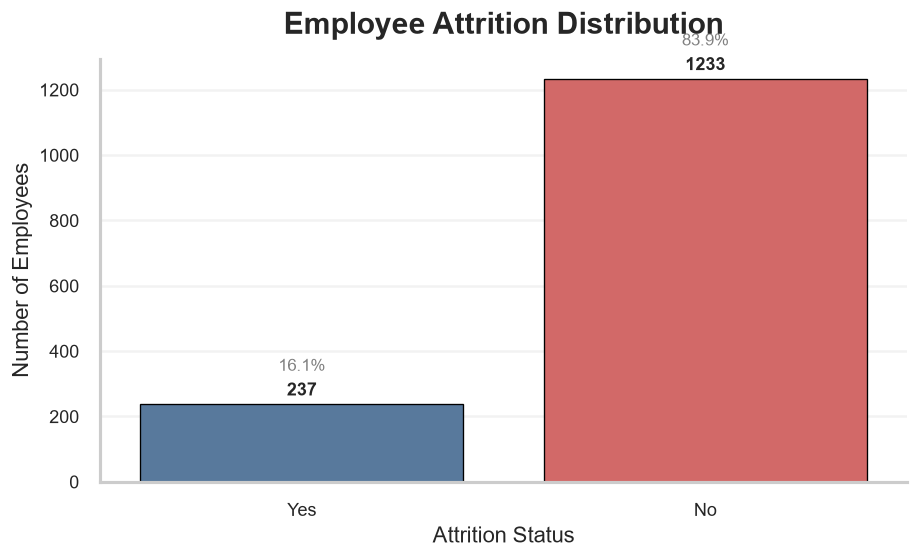

In [32]:
# ==========================================================
# Target Variable Distribution
# ==========================================================

fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Attrition",
    hue="Attrition",
    palette=[PRIMARY, DANGER],
    legend=False,
    edgecolor="black",
    linewidth=0.8,
    ax=ax
)

# Value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=11,
        fontweight="bold",
        padding=3
    )

# Percentage labels
total = len(df)

for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"

    ax.annotate(
        percentage,
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        color="gray",
        xytext=(0, 18),
        textcoords="offset points"
    )

ax.set_title(
    "Employee Attrition Distribution",
    pad=15
)

ax.set_xlabel("Attrition Status")
ax.set_ylabel("Number of Employees")

sns.despine()

plt.tight_layout()
plt.show()

## Key Findings

- The dataset contains 1,470 employee records and 35 features.
- No missing values were detected.
- No duplicate records were identified.
- Several columns (EmployeeCount, Over18, StandardHours) contain constant values and do not contribute predictive information.
- The target variable (Attrition) is imbalanced, with employees who left representing approximately 16% of the dataset.
- Most features appear correctly typed, although categorical variables will require encoding before model training.

These observations indicate that the dataset is generally clean and suitable for further exploratory analysis. The next phase will focus on understanding feature distributions and identifying relationships between employee characteristics and attrition.